# PnPMass with uncertainty quantification

Please check `README.md` before running this notebook.

PnPMass, noise-whitening data-fidelity, defined as
$$
f_\gamma(\kappa) = \frac12 \|\gamma - A\kappa\|_{\Sigma^{-1/2}}^2.
$$
Using DRUNet (noise-level-aware denoiser), forced mean centering, with DeepInverse PnP implementation.

- Uncertainty quantification with moment networks and conformal prediction.
- Also include Wiener and MCALens, for comparison.

In [1]:
%config InlineBackend.figure_format = 'svg'
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import pickle
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch
import deepinv as dinv

from wlmmuq import CONFIG_DATA
import wlmmuq.utils as wlutils
import wlmmuq.data.torch as wlds
import wlmmuq.models.torch as wlnn
import wlmmuq.kappatng as wlktng
import wlmmuq.cosmos as wlcosmos
import wlmmuq.models.deepinv.iterativemm as wlpnp
import wlmmuq.cqr as wlcqr

Configuration file found in /home/leterme231/OneDrive/Documents/Code/weaklensing


/home/leterme231/miniconda3/envs/wl-pycs/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
path_to_test_set = "/home/leterme231/Documents/Data/kappaTNG_cropped/LP001_cropped_384.hdf5"
path_to_models = "/home/leterme231/Documents/Checkpoints"
path_to_ps = "/home/leterme231/Documents/Data/kappaTNG_augmented/ps_LP002_384.pt" # For DeepMass
pickle_dir = "/home/leterme231/OneDrive/Documents/Code/obj" # For saving reconstructions with Wiener and MCALens

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Load COSMOS galaxy shape catalog

In [6]:
imgsize = 384
imgsize_imshow = 304

In [7]:
cat_cosmos_bright, _ = wlcosmos.cosmos_catalog()
cat_cosmos_bright = wlcosmos.filter_by_redshifts(cat_cosmos_bright, wlktng.MAX_Z)
data_dict = wlktng.get_data_from_cosmos_ktng(cat_cosmos_bright, imgsize)
extent = data_dict["extent"]

In [8]:
ra, dec = np.array(wlcosmos.COSMOS_VERTICES).T

In [9]:
shapedisp = data_dict["shapedisp"]
ngal = data_dict["ngal"]
mask = data_dict["mask"]
std_noise = wlutils.get_std_noise(ngal, shapedisp, std_noise_mask=0)

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/utils.py:201: RuntimeWarning: divide by zero encountered in divide
  shapedisp / np.sqrt(ngal), posinf=std_noise_mask


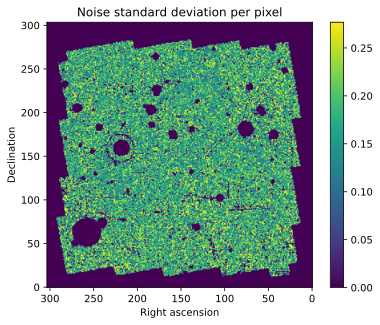

In [10]:
wlutils.skyshow(std_noise, imgsize=imgsize_imshow)
plt.title("Noise standard deviation per pixel")
plt.show()

## Estimate upper bound for step size

$\tau = 2 / \|B\|$, with $B = A^\ast \Sigma^{-1/2} A$.

In [11]:
upperbound_step_size = wlutils.get_sup_step_size(
    std_noise**0.5, # Sqrt of noise stdev because we do not consider the negative log-likelihood
    mask=mask
)

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/utils.py:952: RuntimeWarning: invalid value encountered in divide
  gamma /= std_noise**2


In [12]:
print(f"Upper bound step size = {upperbound_step_size:.2e}")

Upper bound step size = 1.49e-01


In [13]:
std_noise = torch.tensor(std_noise, dtype=torch.float32).to(device)
mask = torch.tensor(mask, dtype=bool).to(device)

In [14]:
nimgs_test = 225
batch_size = 32
num_workers = 8
multfact_step_size = 0.99

In [15]:
step_size = multfact_step_size * upperbound_step_size

## Results training models

- Size of the training set: 70560
- Batch size: 32
- Number of epochs: 20
- Learning rate: 1e-4, decreased by a factor of 10 every 5 epochs

### Training and validation loss

In [16]:
label_denoiser = "DRUNet for PnPMass"
label_deepmass = "SUNet (Wiener init) for DeepMass"

In [17]:
label_pe = "Order-1 networks (mean estimates)"
label_uq = "Order-2 networks (variance estimates)"

In [18]:
dirname_denoiser = "denoiser_torch.DRUNet_model-size_small_scale_0.2_scale-min_0.0_nepochs_100"
dirname_deepmass = "deepmass_torch.SUNetWienerInit_batch-size_16_nepochs_100_learning-rate_1e-3"

In [19]:
filename_denoiser = "ckp_100.pth.tar"
filename_deepmass = "ckp_100.pth.tar"

In [20]:
timestamp_denoiser_pe = "20250613_140201"
timestamp_denoiser_uq = "20250623_100230"

timestamp_deepmass_pe = "20250613_143203"
timestamp_deepmass_uq = "20250623_100904"

In [21]:
path_to_denoiser_pe = os.path.join(
    path_to_models, dirname_denoiser, "pe", timestamp_denoiser_pe, filename_denoiser
)
path_to_denoiser_uq = os.path.join(
    path_to_models, dirname_denoiser, "var", timestamp_denoiser_uq, filename_denoiser
)

path_to_deepmass_pe = os.path.join(
    path_to_models, dirname_deepmass, "pe", timestamp_deepmass_pe, filename_deepmass
)
path_to_deepmass_uq = os.path.join(
    path_to_models, dirname_deepmass, "var", timestamp_deepmass_uq, filename_deepmass
)

In [22]:
colors = [d['color'] for d in plt.rcParams['axes.prop_cycle']]

In [23]:
linestyle_pe = '-'
linestyle_uq = '--'

color_denoiser = colors[0]
color_deepmass = colors[1]

In [24]:
checkpoint_denoiser_pe = torch.load(
    os.path.join(path_to_models, path_to_denoiser_pe)
)
checkpoint_deepmass_pe = torch.load(
    os.path.join(path_to_models, path_to_deepmass_pe)
)

checkpoint_denoiser_uq = torch.load(
    os.path.join(path_to_models, path_to_denoiser_uq)
)
checkpoint_deepmass_uq = torch.load(
    os.path.join(path_to_models, path_to_deepmass_uq)
)

/tmp/ipykernel_57257/2095568913.py:16: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')
/tmp/ipykernel_57257/2095568913.py:29: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


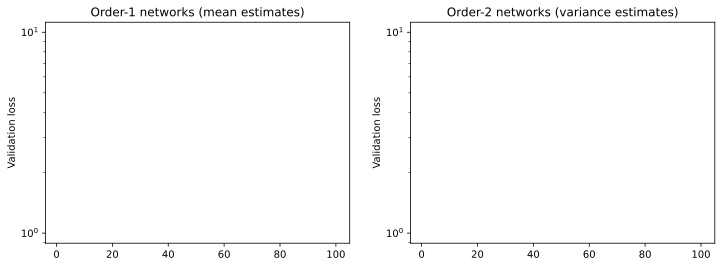

In [25]:
epochs = np.arange(checkpoint_denoiser_pe['epoch']) + 1

plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(
    epochs, checkpoint_denoiser_pe['loss'],
    label=label_denoiser, ls=linestyle_pe, c=color_denoiser
)
plt.plot(
    epochs, checkpoint_deepmass_pe['loss'],
    label=label_deepmass, ls=linestyle_pe, c=color_deepmass
)
plt.ylabel('Validation loss')
plt.title(label_pe)
plt.yscale('log')

plt.subplot(122)
plt.plot(
    epochs, checkpoint_denoiser_uq['loss'],
    label=label_denoiser, ls=linestyle_uq, c=color_denoiser
)
plt.plot(
    epochs, checkpoint_deepmass_uq['loss'],
    label=label_deepmass, ls=linestyle_uq, c=color_deepmass
)
plt.ylabel('Validation loss')
plt.title(label_uq)
plt.yscale('log')

plt.show()

## Load test set

In [26]:
test_dataset = wlds.HDF5DatasetMassMapping(
    hdf5_filepath=path_to_test_set, nimgs=nimgs_test, batch_size=batch_size,
    std_noise=std_noise.cpu(), mask=mask.cpu(), inpainting=True, shuffle=False,
    output_shape=imgsize, newaxis=True, num_workers=0
)
test_dataloader = test_dataset.to_dataloader()

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/data/base_dataset.py:294: UserWarning: The 'filename_ori' dataset is missing; input images will not be sorted or filtered by filename.
  warnings.warn(


## PnPMass

In [27]:
niter = 3

### Load trained models

In [28]:
denoiser_pe = wlnn.DRUNet(
    map_size=imgsize, model_size="small"
)
denoiser_pe.load_state_dict(checkpoint_denoiser_pe['state_dict'])
denoiser_pe.to(device).eval()
denoiser_pe.summary()

Layer (type:depth-idx)                   Output Shape              Param #
DRUNet                                   [1, 1, 384, 384]          --
├─Conv2d: 1-1                            [1, 16, 384, 384]         288
├─Sequential: 1-2                        [1, 32, 192, 192]         --
│    └─ResBlock: 2-1                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-1              [1, 16, 384, 384]         4,640
│    └─ResBlock: 2-2                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-2              [1, 16, 384, 384]         4,640
│    └─ResBlock: 2-3                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-3              [1, 16, 384, 384]         4,640
│    └─ResBlock: 2-4                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-4              [1, 16, 384, 384]         4,640
│    └─AvgPool2d: 2-5                    [1, 16, 192, 192]         --
│    └─Conv2d: 2-6                       [1, 32, 192, 192]         4,608

In [29]:
denoiser_uq = wlnn.DRUNet(
    map_size=imgsize,
    meancentering=False, onlypositive=True, # Config required for variance estimation
    model_size="small"
)
denoiser_uq.load_state_dict(checkpoint_denoiser_uq['state_dict'])
denoiser_uq.to(device).eval()
denoiser_uq.summary()

Layer (type:depth-idx)                   Output Shape              Param #
DRUNet                                   [1, 1, 384, 384]          --
├─Conv2d: 1-1                            [1, 16, 384, 384]         288
├─Sequential: 1-2                        [1, 32, 192, 192]         --
│    └─ResBlock: 2-1                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-1              [1, 16, 384, 384]         4,640
│    └─ResBlock: 2-2                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-2              [1, 16, 384, 384]         4,640
│    └─ResBlock: 2-3                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-3              [1, 16, 384, 384]         4,640
│    └─ResBlock: 2-4                     [1, 16, 384, 384]         --
│    │    └─Sequential: 3-4              [1, 16, 384, 384]         4,640
│    └─AvgPool2d: 2-5                    [1, 16, 192, 192]         --
│    └─Conv2d: 2-6                       [1, 32, 192, 192]         4,608

### Load physics, data fidelity and priors

For the data fidelity, we use the square root of the noise level (non-Bayesian data fidelity):
$$
f_\gamma(\kappa) = \frac12 \|\gamma - A\kappa\|_{\Sigma^{-1/2}}^2.
$$

In [30]:
physics = wlpnp.MassMapping(sigma=std_noise, mask=mask).to(device)
data_fidelity = wlpnp.Mahalanobis(sigma=torch.sqrt(std_noise)).to(device) # torch.sqrt is on purpose

In [31]:
prior = dinv.optim.prior.PnP(denoiser_pe).to(device)
prior_uq = dinv.optim.prior.PnP(denoiser_uq).to(device)
pnpmass = wlpnp.optim_builder(
    iteration="PGD", prior=prior, prior_uq=prior_uq,
    data_fidelity=data_fidelity,
    early_stop=False, max_iter=niter, custom_init=wlpnp.zero_init,
    verbose=True, params_algo={"stepsize": step_size, "g_param": step_size},
) # The step size is equal to the noise level in the denoiser

### Run PnPMass

In [32]:
listof_kappa_pnp_test = []
listof_var_pnp_test = []

In [33]:
test_dataloader_iter = iter(test_dataloader)
while True:
    try:
        _, gamma_noisy_test = next(test_dataloader_iter)
    except StopIteration:
        break
    gamma_noisy_test = gamma_noisy_test.to(device)
    with torch.no_grad():
        kappa_pnp_test, var_pnp_test = pnpmass(gamma_noisy_test, physics)

    listof_kappa_pnp_test.append(kappa_pnp_test)
    listof_var_pnp_test.append(var_pnp_test)

/home/leterme231/miniconda3/envs/wl-pycs/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [34]:
kappa_pnp_test = torch.cat(listof_kappa_pnp_test, dim=0)
var_pnp_test = torch.cat(listof_var_pnp_test, dim=0)

del listof_kappa_pnp_test
del listof_var_pnp_test

## DeepMass

### Get arguments for Wiener initialization

In [35]:
upperbound_step_size_wienerinit = wlutils.get_sup_step_size(
    std_noise, mask=mask
) # Different from the one for PnPMass! Here we consider the negative log-likelihood
step_size_wienerinit = multfact_step_size * upperbound_step_size_wienerinit

powerspectrum_wienerinit = torch.load(path_to_ps)

args_wienerinit = dict(
    step_size=step_size_wienerinit, powerspectrum=powerspectrum_wienerinit,
    std_noise=std_noise, mask=mask
)

### Load trained models

In [36]:
deepmass_pe = wlnn.SUNetWienerInit(
    map_size=imgsize, args_wienerinit=args_wienerinit
)
deepmass_pe.load_state_dict(checkpoint_deepmass_pe['state_dict'])
deepmass_pe.to(device).eval()
deepmass_pe.summary()

Layer (type:depth-idx)                             Output Shape              Param #
SUNetWienerInit                                    [1, 1, 384, 384]          1
├─IterativeWiener: 1-1                             [1, 1, 384, 384]          294,912
│    └─BaseOptim: 2-1                              [1, 1, 384, 384]          --
│    │    └─FixedPoint: 3-1                        [1, 1, 384, 384]          --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23                       --                        --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23                       --                        --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23                       --                        --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23   

In [37]:
deepmass_uq = wlnn.SUNetWienerInit(
    map_size=imgsize, args_wienerinit=args_wienerinit,
    meancentering=False, onlypositive=True # Config required for variance estimation
)
deepmass_uq.load_state_dict(checkpoint_deepmass_uq['state_dict'])
deepmass_uq.to(device).eval()
deepmass_uq.summary()

Layer (type:depth-idx)                             Output Shape              Param #
SUNetWienerInit                                    [1, 1, 384, 384]          1
├─IterativeWiener: 1-1                             [1, 1, 384, 384]          294,912
│    └─BaseOptim: 2-1                              [1, 1, 384, 384]          --
│    │    └─FixedPoint: 3-1                        [1, 1, 384, 384]          --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23                       --                        --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23                       --                        --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23                       --                        --
│    │    └─ModuleList: 3-24                       --                        --
│    │    └─FixedPoint: 3-23   

### Run DeepMass

In [38]:
listof_kappa_deepmass_test = []
listof_var_deepmass_test = []

In [39]:
test_dataloader_iter = iter(test_dataloader)
while True:
    try:
        _, gamma_noisy_test = next(test_dataloader_iter)
    except StopIteration:
        break
    gamma_noisy_test = gamma_noisy_test.to(device)
    with torch.no_grad():
        kappa_deepmass_test = deepmass_pe(gamma_noisy_test)
        var_deepmass_test = deepmass_uq(gamma_noisy_test)

    listof_kappa_deepmass_test.append(kappa_deepmass_test)
    listof_var_deepmass_test.append(var_deepmass_test)

In [40]:
kappa_deepmass_test = torch.cat(listof_kappa_deepmass_test, dim=0)
var_deepmass_test = torch.cat(listof_var_deepmass_test, dim=0)

del listof_kappa_deepmass_test
del listof_var_deepmass_test

## Visualize input, target and prediction

In [41]:
kappa_test, gamma_noisy_test = test_dataset.load_batch(get_all_images=True)
kappa_test = kappa_test.to(device)
gamma_noisy_test = gamma_noisy_test.to(device)

In [42]:
vmin = torch.min(kappa_test).item()
vmax = torch.max(kappa_test).item()
saturation = 0.4
vmax_gamma = 0.14
vmax_sqdiff = 4e-3

In [43]:
idx = 0

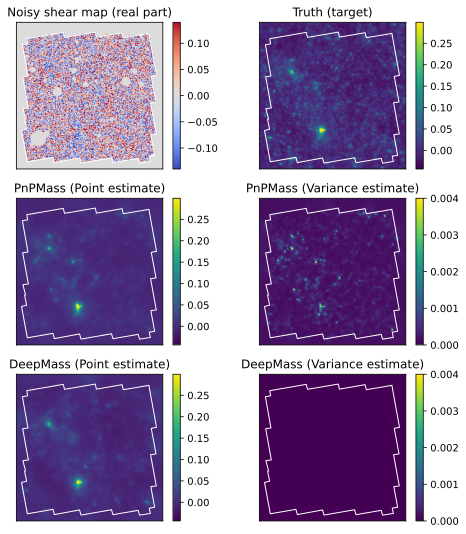

In [44]:
plt.figure(figsize=(8, 9))
plt.subplot(321)
wlutils.skyshow(
    gamma_noisy_test.real.cpu()[idx, 0], title=f"Noisy shear map (real part)",
    cmap="coolwarm", vmin=-vmax_gamma, vmax=vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(322)
wlutils.skyshow(
    kappa_test.cpu()[idx, 0], title="Truth (target)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(323)
wlutils.skyshow(
    kappa_pnp_test.cpu()[idx, 0], title="PnPMass (Point estimate)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(324)
wlutils.skyshow(
    var_pnp_test.cpu()[idx, 0], title="PnPMass (Variance estimate)",
    vmin=0., vmax=vmax_sqdiff, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(325)
wlutils.skyshow(
    kappa_deepmass_test.cpu()[idx, 0], title="DeepMass (Point estimate)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(326)
wlutils.skyshow(
    var_deepmass_test.cpu()[idx, 0], title="DeepMass (Variance estimate)",
    vmin=0., vmax=vmax_sqdiff, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.show()

## Wiener and MCALens

Convergence maps reconstructed with the following scripts (commit nb `dde28a1cddfa0aa84037a1690d13e9d23b8d9603`):
```bash
python scripts/massmapping.py wiener wiener_niter_12_nimgs_225_${datetime} /home/leterme231/Documents/Data/kappaTNG_cropped/LP001_cropped.hdf5 --niter 12 --nimgs 225 -b 45 --seed 42 -v
```
```bash
python scripts/massmapping.py mcalens mcalens_niter_${niter_mcalens}_Nsigma_5_nimgs_225_${datetime} /home/leterme231/Documents/Data/kappaTNG_cropped/LP001_cropped.hdf5 --niter $niter_mcalens --Nsigma 5 --nimgs 225 -b 45 --seed 42 -v
```

In [45]:
# TODO: to be updated with images of size 384x384

In [46]:
label_pnpmass = "PnPMass"
label_deepmass_0 = "DeepMass"
# label_wiener = "Wiener"
# label_mcalens_niter_12 = "MCALens (12 iterations)"
# label_mcalens_niter_100 = "MCALens (100 iterations)"

In [47]:
# filename_wiener_test = 'wiener_niter_12_nimgs_225_20250425_161425.npy'
# filename_mcalens_niter_12_test = 'mcalens_niter_12_Nsigma_5_nimgs_225_20250425_161238.npy'
# filename_mcalens_niter_100_test = 'mcalens_niter_100_Nsigma_5_nimgs_225_20250425_161218.npy'

In [48]:
# kappa_wiener_test = np.load(os.path.join(pickle_dir, filename_wiener_test))
# kappa_mcalens_niter_12_test = np.load(os.path.join(pickle_dir, filename_mcalens_niter_12_test))
# kappa_mcalens_niter_100_test = np.load(os.path.join(pickle_dir, filename_mcalens_niter_100_test))

In [49]:
# kappa_wiener_test = torch.tensor(kappa_wiener_test, dtype=torch.float32).to(device)
# kappa_mcalens_niter_12_test = torch.tensor(kappa_mcalens_niter_12_test, dtype=torch.float32).to(device)
# kappa_mcalens_niter_100_test = torch.tensor(kappa_mcalens_niter_100_test, dtype=torch.float32).to(device)

In [50]:
# plt.figure(figsize=(8, 6))
# plt.subplot(221)
# wlutils.skyshow(
#     kappa_test.cpu()[idx, 0], title="Truth (target)",
#     vmin=vmin, vmax=saturation*vmax, extent=extent,
#     boundaries=(ra, dec), printxylabels=False,
#     printxticks=False, printyticks=False, printcolorbar=True,
#     imgsize=imgsize_imshow
# )
# plt.subplot(222)
# wlutils.skyshow(
#     kappa_wiener_test.cpu()[idx], title=label_wiener,
#     vmin=vmin, vmax=saturation*vmax, extent=extent,
#     boundaries=(ra, dec), printxylabels=False,
#     printxticks=False, printyticks=False, printcolorbar=True,
#     imgsize=imgsize_imshow
# )
# plt.subplot(223)
# wlutils.skyshow(
#     kappa_mcalens_niter_12_test.cpu()[idx], title=label_mcalens_niter_12,
#     vmin=vmin, vmax=saturation*vmax, extent=extent,
#     boundaries=(ra, dec), printxylabels=False,
#     printxticks=False, printyticks=False, printcolorbar=True,
#     imgsize=imgsize_imshow
# )
# plt.subplot(224)
# wlutils.skyshow(
#     kappa_mcalens_niter_100_test.cpu()[idx], title=label_mcalens_niter_100,
#     vmin=vmin, vmax=saturation*vmax, extent=extent,
#     boundaries=(ra, dec), printxylabels=False,
#     printxticks=False, printyticks=False, printcolorbar=True,
#     imgsize=imgsize_imshow
# )
# plt.show()

## Uncertainty quantification

### UQ parameters

In [51]:
confidence = 2. # Level of confidence (n-sigma)
alpha = wlutils.get_alpha_from_confidence(confidence)

min_nimgs_calib = wlutils.get_min_nimgs_calib(alpha)
print(f"Confidence level of {confidence}-sigma --> alpha = {alpha:.1%}")
print(f"Smallest possible size for the calibration set = {min_nimgs_calib}")

Confidence level of 2.0-sigma --> alpha = 4.6%
Smallest possible size for the calibration set = 21


In [52]:
nimgs_calib = 100
nimgs_test -= nimgs_calib

### Remove channel dimension from tensors

In [53]:
kappa_test = kappa_test.squeeze(-3)
kappa_pnp_test = kappa_pnp_test.squeeze(-3)
kappa_deepmass_test = kappa_deepmass_test.squeeze(-3)
var_pnp_test = var_pnp_test.squeeze(-3)
var_deepmass_test = var_deepmass_test.squeeze(-3)

### Get residuals

In [54]:
std_pnp_test = torch.sqrt(var_pnp_test)
std_deepmass_test = torch.sqrt(var_deepmass_test)
res_pnp_test = confidence * std_pnp_test
res_deepmass_test = confidence * std_deepmass_test

Wiener and MCALens: no initial UQ

In [55]:
# res_wiener_test = 0.
# res_mcalens_niter_12_test = 0.
# res_mcalens_niter_100_test = 0.

### Split test and calibration sets

In [56]:
[
    kappa_calib,
    kappa_pnp_calib, kappa_deepmass_calib,
    # kappa_wiener_calib, kappa_mcalens_niter_12_calib, kappa_mcalens_niter_100_calib,
    res_pnp_calib, res_deepmass_calib,
    # res_wiener_calib, res_mcalens_niter_12_calib, res_mcalens_niter_100_calib
], [
    kappa_test,
    kappa_pnp_test, kappa_deepmass_test,
    # kappa_wiener_test, kappa_mcalens_niter_12_test, kappa_mcalens_niter_100_test,
    res_pnp_test, res_deepmass_test,
    # res_wiener_test, res_mcalens_niter_12_test, res_mcalens_niter_100_test
] = wlutils.split_test_calib(
    [
        kappa_test,
        kappa_pnp_test, kappa_deepmass_test,
        # kappa_wiener_test, kappa_mcalens_niter_12_test, kappa_mcalens_niter_100_test,
        res_pnp_test, res_deepmass_test,
        # res_wiener_test, res_mcalens_niter_12_test, res_mcalens_niter_100_test
    ],
    nimgs_calib, calib_first=False
) # First the test set; then the calibration set

print(f"Size of the calibration set = {kappa_calib.shape[0]}")
print(f"Size of the test set = {kappa_test.shape[0]}")

Size of the calibration set = 100
Size of the test set = 125


### Compute reconstruction accuracy

In [57]:
rmse_pnp_test = wlutils.rmse(
    kappa_pnp_test, kappa_test, mask=mask
)
rmse_deepmass_test = wlutils.rmse(
    kappa_deepmass_test, kappa_test, mask=mask
)
# rmse_wiener_test = wlutils.rmse(
#     kappa_wiener_test, kappa_test, mask=mask
# )
# rmse_mcalens_niter_12_test = wlutils.rmse(
#     kappa_mcalens_niter_12_test, kappa_test, mask=mask
# )
# rmse_mcalens_niter_100_test = wlutils.rmse(
#     kappa_mcalens_niter_100_test, kappa_test, mask=mask
# )

In [58]:
om = 3
print(
    f"{label_pnpmass} --> RMSE = {10**om * torch.mean(rmse_pnp_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(rmse_pnp_test):.2f}e-{om}"
)
print(
    f"{label_deepmass_0} --> RMSE = {10**om * torch.mean(rmse_deepmass_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(rmse_deepmass_test):.2f}e-{om}"
)
# print(
#     f"{label_wiener} --> RMSE = {10**om * torch.mean(rmse_wiener_test):.2f}e-{om} "
#     f"+/- {1e3*torch.std(rmse_wiener_test):.2f}e-{om}"
# )
# print(
#     f"{label_mcalens_niter_12} --> RMSE = {10**om * torch.mean(rmse_mcalens_niter_12_test):.2f}e-{om} "
#     f"+/- {1e3*torch.std(rmse_mcalens_niter_12_test):.2f}e-{om}"
# )
# print(
#     f"{label_mcalens_niter_100} --> RMSE = {10**om * torch.mean(rmse_mcalens_niter_100_test):.2f}e-{om} "
#     f"+/- {1e3*torch.std(rmse_mcalens_niter_100_test):.2f}e-{om}"
# )

PnPMass --> RMSE = 17.70e-3 +/- 0.95e-3
DeepMass --> RMSE = 17.45e-3 +/- 0.96e-3


### CQR

In [59]:
addcqr = wlcqr.AddCQR(alpha)

In [60]:
res_pnp_addcqr_test, _, _ = addcqr.conformalize(
    res_pnp_test, kappa_pnp_calib, res_pnp_calib, kappa_calib
)
res_deepmass_addcqr_test, _, _ = addcqr.conformalize(
    res_deepmass_test, kappa_deepmass_calib, res_deepmass_calib, kappa_calib
)
# res_wiener_addcqr_test, _, _ = addcqr.conformalize(
#     res_wiener_test, kappa_wiener_calib, res_wiener_calib, kappa_calib
# )
# res_mcalens_niter_12_addcqr_test, _, _ = addcqr.conformalize(
#     res_mcalens_niter_12_test, kappa_mcalens_niter_12_calib,
#     res_mcalens_niter_12_calib, kappa_calib
# )
# res_mcalens_niter_100_addcqr_test, _, _ = addcqr.conformalize(
#     res_mcalens_niter_100_test, kappa_mcalens_niter_100_calib,
#     res_mcalens_niter_100_calib, kappa_calib
# )

### Visualize bounds

In [61]:
skyshow_pred_bounds = wlutils.KappamapVisualizer(
    extent=extent, boundaries=(ra, dec), vmin=saturation*vmin, vmax=saturation*vmax,
    vmax_bounds=0.23, plot_colorbar=True
)

lowerbound_pnpmass, upperbound_pnpmass = skyshow_pred_bounds(
    kappa_pnp_test[idx], res_pnp_addcqr_test[idx],
    kappa_test[idx], mask=mask
)
lowerbound_deepmass, upperbound_deepmass = skyshow_pred_bounds(
    kappa_deepmass_test[idx], res_deepmass_addcqr_test[idx],
    kappa_test[idx], mask=mask
)
# lowerbound_wiener, upperbound_wiener = skyshow_pred_bounds(
#     kappa_wiener_test[idx], res_wiener_addcqr_test[idx],
#     kappa_test[idx], mask=mask
# )
# lowerbound_mcalens_niter_12, upperbound_mcalens_niter_12 = skyshow_pred_bounds(
#     kappa_mcalens_niter_12_test[idx], res_mcalens_niter_12_addcqr_test[idx],
#     kappa_test[idx], mask=mask
# )
# lowerbound_mcalens_niter_100, upperbound_mcalens_niter_100 = skyshow_pred_bounds(
#     kappa_mcalens_niter_100_test[idx], res_mcalens_niter_100_addcqr_test[idx],
#     kappa_test[idx], mask=mask
# )

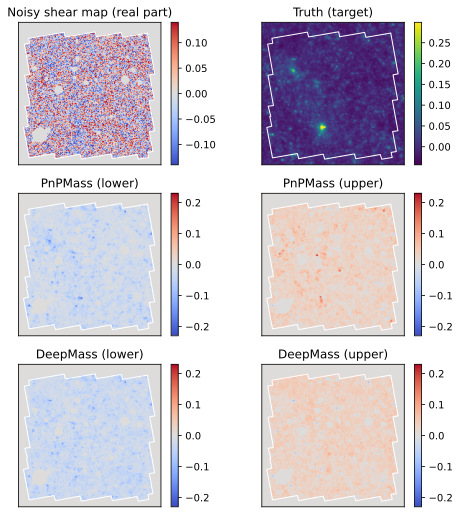

In [62]:
plt.figure(figsize=(8, 18))
plt.subplot(6, 2, 1)
wlutils.skyshow(
    gamma_noisy_test.real.cpu()[idx, 0], title=f"Noisy shear map (real part)",
    cmap="coolwarm", vmin=-vmax_gamma, vmax=vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(6, 2, 2)
wlutils.skyshow(
    kappa_test.cpu()[idx], title="Truth (target)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(6, 2, 3)
skyshow_pred_bounds.skyshow_bound(
    lowerbound_pnpmass, title=f"{label_pnpmass} (lower)",
    imgsize=imgsize_imshow
)
plt.subplot(6, 2, 4)
skyshow_pred_bounds.skyshow_bound(
    upperbound_pnpmass, title=f"{label_pnpmass} (upper)",
    imgsize=imgsize_imshow
)
plt.subplot(6, 2, 5)
skyshow_pred_bounds.skyshow_bound(
    lowerbound_deepmass, title=f"{label_deepmass_0} (lower)",
    imgsize=imgsize_imshow
)
plt.subplot(6, 2, 6)
skyshow_pred_bounds.skyshow_bound(
    upperbound_deepmass, title=f"{label_deepmass_0} (upper)",
    imgsize=imgsize_imshow
)
# plt.subplot(6, 2, 7)
# skyshow_pred_bounds.skyshow_bound(
#     lowerbound_wiener, title=f"{label_wiener} (lower)",
#     imgsize=imgsize_imshow
# )
# plt.subplot(6, 2, 8)
# skyshow_pred_bounds.skyshow_bound(
#     upperbound_wiener, title=f"{label_wiener} (upper)",
#     imgsize=imgsize_imshow
# )
# plt.subplot(6, 2, 9)
# skyshow_pred_bounds.skyshow_bound(
#     lowerbound_mcalens_niter_12, title=f"{label_mcalens_niter_12} (lower)",
#     imgsize=imgsize_imshow
# )
# plt.subplot(6, 2, 10)
# skyshow_pred_bounds.skyshow_bound(
#     upperbound_mcalens_niter_12, title=f"{label_mcalens_niter_12} (upper)",
#     imgsize=imgsize_imshow
# )
# plt.subplot(6, 2, 11)
# skyshow_pred_bounds.skyshow_bound(
#     lowerbound_mcalens_niter_100, title=f"{label_mcalens_niter_100} (lower)",
#     imgsize=imgsize_imshow
# )
# plt.subplot(6, 2, 12)
# skyshow_pred_bounds.skyshow_bound(
#     upperbound_mcalens_niter_100, title=f"{label_mcalens_niter_100} (upper)",
#     imgsize=imgsize_imshow
# )
plt.show()

### Miscoverage rate (all pixels)

In [63]:
ylabel_err = \
    r"$L\left(\boldsymbol{\kappa}_i,\, \hat{\boldsymbol{\kappa}}_i^-,\, \hat{\boldsymbol{\kappa}}_i^+\right)$"
xticklabels = ['Uncalibrated', 'Additive CQR']

In [64]:
lower_bound_proba, upper_bound_proba = addcqr.get_bounds_proba(nimgs_calib)

In [65]:
err_pnp_test, _, _, _ = wlutils.get_metrics(
    kappa_pnp_test, res_pnp_test, kappa_test, mask=mask
)
err_pnp_addcqr_test, _, _, _ = wlutils.get_metrics(
    kappa_pnp_test, res_pnp_addcqr_test, kappa_test, mask=mask
)

In [66]:
err_deepmass_test, _, _, _ = wlutils.get_metrics(
    kappa_deepmass_test, res_deepmass_test, kappa_test, mask=mask
)
err_deepmass_addcqr_test, _, _, _ = wlutils.get_metrics(
    kappa_deepmass_test, res_deepmass_addcqr_test, kappa_test, mask=mask
)

We do not compute the error rate before calibration for Wiener and MCALens (it would be 100%).

In [67]:
# err_wiener_addcqr_test, _, _, _ = wlutils.get_metrics(
#     kappa_wiener_test, res_wiener_addcqr_test, kappa_test, mask=mask
# )
# err_mcalens_niter_12_addcqr_test, _, _, _ = wlutils.get_metrics(
#     kappa_mcalens_niter_12_test, res_mcalens_niter_12_addcqr_test, kappa_test, mask=mask
# )
# err_mcalens_niter_100_addcqr_test, _, _, _ = wlutils.get_metrics(
#     kappa_mcalens_niter_100_test, res_mcalens_niter_100_addcqr_test, kappa_test, mask=mask
# )

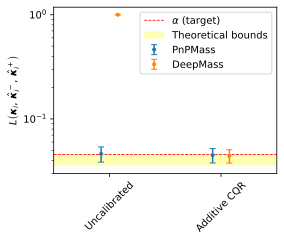

In [68]:
wlutils.plot_means_errs(
    [
        [err_pnp_test.mean().cpu(), err_pnp_addcqr_test.mean().cpu()],
        [err_deepmass_test.mean().cpu(), err_deepmass_addcqr_test.mean().cpu()],
        # [None, err_wiener_addcqr_test.mean().cpu()],
        # [None, err_mcalens_niter_12_addcqr_test.mean().cpu()],
        # [None, err_mcalens_niter_100_addcqr_test.mean().cpu()]
    ],
    [
        [err_pnp_test.std().cpu(), err_pnp_addcqr_test.std().cpu()],
        [err_deepmass_test.std().cpu(), err_deepmass_addcqr_test.std().cpu()],
        # [None, err_wiener_addcqr_test.std().cpu()],
        # [None, err_mcalens_niter_12_addcqr_test.std().cpu()],
        # [None, err_mcalens_niter_100_addcqr_test.std().cpu()]
    ],
    [
        label_pnpmass, label_deepmass_0,
        # label_wiener, label_mcalens_niter_12, label_mcalens_niter_100
    ], xticklabels=xticklabels, alpha=alpha,
    ylabel=ylabel_err, drawbounds=True, y_lower=lower_bound_proba, y_upper=upper_bound_proba,
    ymin=0.03, figsize=(4, 3), logscale=True, savefig=False
)

### Mean length of prediction intervals

In [69]:
predinterv_pnp_test = wlutils.mean_predinterv(
    kappa_pnp_test - res_pnp_test,
    kappa_pnp_test + res_pnp_test,
    mask=mask
)
predinterv_pnp_addcqr_test = wlutils.mean_predinterv(
    kappa_pnp_test - res_pnp_addcqr_test,
    kappa_pnp_test + res_pnp_addcqr_test,
    mask=mask
)

In [70]:
predinterv_deepmass_test = wlutils.mean_predinterv(
    kappa_deepmass_test - res_deepmass_test,
    kappa_deepmass_test + res_deepmass_test,
    mask=mask
)
predinterv_deepmass_addcqr_test = wlutils.mean_predinterv(
    kappa_deepmass_test - res_deepmass_addcqr_test,
    kappa_deepmass_test + res_deepmass_addcqr_test,
    mask=mask
)

We do not compute the error bar sizes before calibration for Wiener and MCALens (it would be 0).

In [71]:
# predinterv_wiener_addcqr_test = wlutils.mean_predinterv(
#     kappa_wiener_test - res_wiener_addcqr_test,
#     kappa_wiener_test + res_wiener_addcqr_test,
#     mask=mask
# )
# predinterv_mcalens_niter_12_addcqr_test = wlutils.mean_predinterv(
#     kappa_mcalens_niter_12_test - res_mcalens_niter_12_addcqr_test,
#     kappa_mcalens_niter_12_test + res_mcalens_niter_12_addcqr_test,
#     mask=mask
# )
# predinterv_mcalens_niter_100_addcqr_test = wlutils.mean_predinterv(
#     kappa_mcalens_niter_100_test - res_mcalens_niter_100_addcqr_test,
#     kappa_mcalens_niter_100_test + res_mcalens_niter_100_addcqr_test,
#     mask=mask
# )

In [72]:
om = 3
print(f"{label_pnpmass}:")
print(
    f"    mean length before calibration = {10**om * torch.mean(predinterv_pnp_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_pnp_test):.2f}e-{om}"
)
print(
    f"    mean length after calibration = {10**om * torch.mean(predinterv_pnp_addcqr_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_pnp_addcqr_test):.2f}e-{om}"
)
print(f"{label_deepmass_0}:")
print(
    f"    mean length before calibration = {10**om * torch.mean(predinterv_deepmass_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_deepmass_test):.2f}e-{om}"
)
print(
    f"    mean length after calibration = {10**om * torch.mean(predinterv_deepmass_addcqr_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_deepmass_addcqr_test):.2f}e-{om}"
)
# print(f"{label_wiener}:")
# print(
#     f"    mean length after calibration = {10**om * torch.mean(predinterv_wiener_addcqr_test):.2f}e-{om} "
#     f"+/- {1e3*torch.std(predinterv_wiener_addcqr_test):.2f}e-{om}"
# )
# print(f"{label_mcalens_niter_12}:")
# print(
#     f"    mean length after calibration = {10**om * torch.mean(predinterv_mcalens_niter_12_addcqr_test):.2f}e-{om} "
#     f"+/- {1e3*torch.std(predinterv_mcalens_niter_12_addcqr_test):.2f}e-{om}"
# )
# print(f"{label_mcalens_niter_100}:")
# print(
#     f"    mean length after calibration = {10**om * torch.mean(predinterv_mcalens_niter_100_addcqr_test):.2f}e-{om} "
#     f"+/- {1e3*torch.std(predinterv_mcalens_niter_100_addcqr_test):.2f}e-{om}"
# )

PnPMass:
    mean length before calibration = 61.40e-3 +/- 0.39e-3
    mean length after calibration = 66.40e-3 +/- 0.39e-3
DeepMass:
    mean length before calibration = 0.00e-3 +/- 0.00e-3
    mean length after calibration = 71.43e-3 +/- 0.00e-3


## Summary plot

### Plot statistics

In [73]:
rmse = [
    # rmse_wiener_test.mean().item(),
    # rmse_mcalens_niter_12_test.mean().item(),
    # rmse_mcalens_niter_100_test.mean().item(),
    rmse_deepmass_test.mean().item(),
    rmse_pnp_test.mean().item()
]
rmse = np.array(rmse)

In [74]:
predinterv = [
    # None,
    # None,
    # None,
    predinterv_deepmass_test.mean().item(),
    predinterv_pnp_test.mean().item()
]
predinterv_addcqr = [
    # predinterv_wiener_addcqr_test.mean().item(),
    # predinterv_mcalens_niter_12_addcqr_test.mean().item(),
    # predinterv_mcalens_niter_100_addcqr_test.mean().item(),
    predinterv_deepmass_addcqr_test.mean().item(),
    predinterv_pnp_addcqr_test.mean().item()
]
predinterv = np.array(predinterv)
predinterv_addcqr = np.array(predinterv_addcqr)

In [75]:
err = [
    # None,
    # None,
    # None,
    err_deepmass_test.mean().item(),
    err_pnp_test.mean().item()
]
err_addcqr = [
    # err_wiener_addcqr_test.mean().item(),
    # err_mcalens_niter_12_addcqr_test.mean().item(),
    # err_mcalens_niter_100_addcqr_test.mean().item(),
    err_deepmass_addcqr_test.mean().item(),
    err_pnp_addcqr_test.mean().item()
]
err = np.array(err)
err_addcqr = np.array(err_addcqr)

In [76]:
methods = [
    # label_wiener, label_mcalens_niter_12, label_mcalens_niter_100,
    label_deepmass_0, label_pnpmass
]

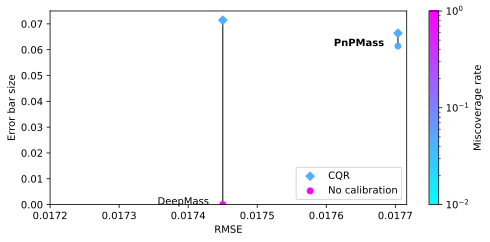

In [77]:
colormap = cm.cool
norm = mcolors.LogNorm(vmin=0.01, vmax=1.)

plt.figure(figsize=(8, 3.5))

plt.scatter(
    rmse, predinterv_addcqr,
    marker="D", c=err_addcqr,
    cmap=colormap, norm=norm, label="CQR", zorder=2
)
mask = predinterv != None # Array of booleans. Do not use `predinterv is not None` as it returns False
sc = plt.scatter(
    rmse[mask], predinterv[mask],
    marker="o", c=err[mask],
    cmap=colormap, norm=norm, label="No calibration", zorder=2
)

plt.vlines(
    rmse[mask], ymin=predinterv[mask],
    ymax=predinterv_addcqr[mask], colors='k', linewidth=1., zorder=1
)

x_offsets = [
    # -2e-5, -2e-5, -2e-5,
    -2e-5, -2e-5
]
y_offsets = [
    # 0., -0.003, 0.,
    0., 0.,
]
positions = [
    # "right", "right", "right",
    "right", "right"
]
weights = [
    # "normal", "normal", "normal",
    "normal", "bold"
]
altitudes = []
for y, z in zip(predinterv, predinterv_addcqr):
    if y is not None:
        altitudes.append(y)
    else:
        altitudes.append(z)
for x, y, x_off, y_off, method, pos, wgt in zip(
        rmse, altitudes, x_offsets, y_offsets, methods, positions, weights
):
    plt.text(x + x_off, y + y_off, method, ha=pos, weight=wgt)

plt.ylim(bottom=0.)
plt.xlabel("RMSE")
plt.ylabel("Error bar size")
plt.legend(loc="lower right")
cbar = plt.colorbar(sc)
cbar.set_label("Miscoverage rate")
# plt.xscale("log")
plt.xlim(left=0.0172)

plt.show()